In [12]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict, Literal
import json, random
from tqdm import tqdm
import os

from dotenv import load_dotenv
load_dotenv()


True

# Load Fold 5 Datasets

In [40]:
# Setting file paths
fold_path = os.path.join(os.path.dirname(os.getcwd()), 'data', 'pqal_fold5')
train_data = json.load(open(os.path.join(fold_path, "train_set.json")))
dev_data = json.load(open(os.path.join(fold_path, "dev_set.json")))

print(f"# Train examples: {len(train_data)}")
print(f"# Dev examples: {len(dev_data)}")


# Train examples: 450
# Dev examples: 50


# Select Few-Shot Examples from Train Set

In [41]:
import random
from collections import defaultdict

# Group by label
yes_examples = [v for v in train_data.values() if v["final_decision"] == "yes"]
no_examples = [v for v in train_data.values() if v["final_decision"] == "no"]
maybe_examples = [v for v in train_data.values() if v["final_decision"] == "maybe"]

# Sample equal number from each (e.g., 5 each)
sample_size = 3
few_shot_curated = random.sample(yes_examples, sample_size) + \
                   random.sample(no_examples, sample_size) + \
                   random.sample(maybe_examples, sample_size)

# Shuffle to avoid label-order bias
random.shuffle(few_shot_curated)

few_shot_curated = [
    {
        "question": ex["QUESTION"],
        "context": ex["CONTEXTS"],
        "rationale": ex["LONG_ANSWER"],
        "answer": ex["final_decision"]
    }
    for ex in few_shot_curated
]


import pandas as pd
import IPython.display as disp
disp.display(pd.DataFrame(few_shot_curated))

,question,context,rationale,answer
0,Is routine intraoperative frozen-section exami...,[Routine intraoperative frozen section (FS) of...,"In breast cancer patients having SLN biopsy, t...",maybe
1,"Knee extensor strength, dynamic stability, and...",[To evaluate the relationship between knee ext...,These findings suggest a malleable relationshi...,yes
2,Spleen-preserving distal pancreatectomy with r...,[Knowing the collaterals is essential for a sp...,"Experimental, intra- and postoperative instrum...",no
3,Are tuberculosis patients adherent to prescrib...,[Tuberculosis (TB) patients face numerous diff...,"Despite recent efforts, a large proportion of ...",maybe
4,Can you deliver accurate tidal volume by manua...,[One of the problems with manual resuscitators...,The tidal volume delivered by a manual resusci...,no
5,Search engine as a diagnostic tool in difficul...,[Web search engines are an important tool in c...,This Google-based search was useful to identif...,yes
6,"""Would a man smell a rose then throw it away?",[Breast cancer is the most common malignancy a...,Jordanian men perceive themselves as having a ...,maybe
7,Clinical identifiers for early-stage primary/i...,[Adhesive capsulitis is often difficult to dia...,None of the clinical identifiers for early-sta...,no
8,Does TDP-43 type confer a distinct pattern of ...,[To determine whether TDP-43 type is associate...,Although there are different patterns of atrop...,yes


# Define Prompt Template

In [42]:
def build_prompt(example, few_shot):
    cot_instruction = (
        "You are a clinical research assistant. Read the study context carefully, "
        "reason step by step based on the evidence, and then answer the question with 'yes', 'no', or 'maybe'."
        "If the evidence is inconclusive, contradictory, or lacks sufficient information, answer 'maybe'"
    )
    
    prompt_text = cot_instruction + "\n\n"

    for fs in few_shot:
        prompt_text += (
            f"Context: {fs['context']}\n"
            f"Question: {fs['question']}\n"
            "Let's think step by step.\n"
            f"{fs['rationale']}\n"
            f"Answer: {fs['answer']}\n\n"
        )
    
    prompt_text += (
        f"Context: {example['context']}\n"
        f"Question: {example['question']}\n"
        "Let's think step by step.\n"
    )
    
    return prompt_text


# Add CoT output parser

In [43]:
import re

def extract_final_answer(response_text: str) -> str:
    match = re.search(r"answer\s*[:\-]?\s*(yes|no|maybe)", response_text.lower())
    if match:
        return match.group(1)
    for word in reversed(response_text.strip().lower().split()):
        if word in {"yes", "no", "maybe"}:
            return word
    return "maybe"  # conservative fallback


# Define output schema

In [44]:
# class AnswerOutput(TypedDict):
#     answer: Literal["yes", "no", "maybe"]

class AgentState(TypedDict):
    question: str
    context: str
    rationale: str  # new field for CoT
    answer: Literal["yes", "no", "maybe"]



llm = ChatOpenAI(model="gpt-4o-mini")

# prompt_node = lambda x: {"content": build_prompt(x, few_shot_examples)}
# llm_node = llm.with_structured_output(AnswerOutput)


# Define Graph Flow

In [45]:
from langgraph.graph import StateGraph

builder = StateGraph(state_schema=AgentState)


# Define the function normally
# def ask_llm(state: AgentState) -> AgentState:
#     prompt_text = build_prompt(state, few_shot_curated)
#     response = llm.invoke([HumanMessage(content=prompt_text)])
#     full_response = response.content.strip()

#     return {
#         **state,
#         "rationale": full_response,
#         "answer": extract_final_answer(full_response)
#     }

from collections import Counter

def ask_llm(state: AgentState, k: int = 5) -> AgentState:
    prompt_text = build_prompt(state, few_shot_curated)

    # Run the LLM k times and collect responses
    responses = []
    for _ in range(k):
        response = llm.invoke([HumanMessage(content=prompt_text)])
        content = response.content.strip()
        responses.append(content)

    # Extract final answers from each response
    answers = [extract_final_answer(r) for r in responses]
    vote_counts = Counter(answers)
    majority_answer = vote_counts.most_common(1)[0][0]

    return {
        **state,
        "rationale": "\n\n---\n\n".join(responses),  # optionally store all rationales
        "answer": majority_answer
    }

# Then register it with the graph
builder.add_node("ask_llm", ask_llm)
builder.set_entry_point("ask_llm")
graph = builder.compile()


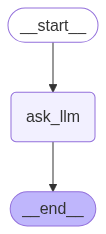

In [46]:
from IPython.display import Image

# Show graph as PNG (may be incomplete — doesn’t show conditional edges)
Image(graph.get_graph().draw_mermaid_png())

# Run Inference

In [47]:
from langchain_core.messages import HumanMessage

# Test example
sample_question = {
    "question": "Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?",
    "context": """
    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",
            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to \"rapid advancement to full enteral feeds\" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid advancement (RA), or \"slow advancement to full enteral feeds\" (median duration of advancement to full enteral feeds>12.5 days; 7 centers), that is, slow advancement (SA).",
            "VLBW infants born in centers with SA (n = 713) had a significantly higher rate of sepsis compared with VLBW infants born in centers with RA (n = 717), which was particularly evident for late-onset sepsis (14.0% vs 20.4%; P = 0.002). Furthermore, more central venous lines (48.6% vs 31.1%, P<0.001) and antibiotics (92.4% vs 77.7%, P<0.001) were used in centers with SA."""
,
    "answer": None  # Include this if `answer` is part of your state schema
}


result = graph.invoke(sample_question)
print(result)


{'question': 'Does the enteral feeding advancement affect short-term outcomes in very low birth weight infants?', 'context': '\n    Controversy exists regarding the optimal enteral feeding regimen of very low birth weight infants (VLBW). Rapid advancement of enteral feeding has been associated with an increased rate of necrotizing enterocolitis. In contrast, delaying enteral feeding may have unfavorable effects on nutrition, growth, and neurodevelopment. The aim is to compare the short-term outcomes of VLBW infants in tertiary care centers according to their enteral feeding advancement.",\n            "We prospectively studied the influence of center-specific enteral feeding advancement in 1430 VLBW infants recruited from 13 tertiary neonatal intensive care units in Germany on short-term outcome parameters. The centers were post hoc stratified to "rapid advancement to full enteral feeds" (median duration of advancement to full enteral feeds<or =12.5 days; 6 centers), that is, rapid adv

In [48]:
print(result['answer'])

yes


yes


# Run Agent on Dev Set

In [49]:
predictions = {}
for pmid, item in tqdm(dev_data.items()):
    q = item["QUESTION"]
    context = "\n".join(item["CONTEXTS"])
    # prompt = build_prompt(q, context, few_shot=few_shot_examples)
    response = graph.invoke({
        "question": q,
        "context": context,
        "rationale":None,
        "answer": None
    })["answer"]
    # if response not in {"yes", "no", "maybe"}:
    #     response = "maybe"
    predictions[pmid] = response


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [07:58<00:00,  9.57s/it]


In [50]:
output_path = os.path.join(os.path.dirname(os.getcwd()), 'outputs', 'fold5_predictions_chain_cot_majority.json')
os.makedirs(os.path.dirname(output_path), exist_ok=True)
# output_path.parent.mkdir(exist_ok=True)
with open(output_path, "w") as f:
    json.dump(predictions, f, indent=2)
print("Saved predictions to", output_path)


Saved predictions to E:\000UC_Berkeley\Others\Job Application\Clinical Literature Agent\pubmed-qa-llm\outputs\fold5_predictions_chain_cot_majority.json


# Evaluating results

In [51]:
from sklearn.metrics import classification_report, accuracy_score

# Load ground truth (dev set from Fold 5)
ground_truth = {k: v["final_decision"] for k, v in dev_data.items()}
human_reasoning_free = {k: v["reasoning_free_pred"] for k, v in dev_data.items()}
human_reasoning_required = {k: v["reasoning_required_pred"] for k, v in dev_data.items()}

# Load your model predictions
with open(output_path) as f:
    predictions = json.load(f)

# Collect model and human predictions
y_true = []
y_pred_model = []
y_pred_human_free = []
y_pred_human_required = []

for pmid, true_label in ground_truth.items():
    if pmid in predictions:
        y_true.append(true_label.lower())
        y_pred_model.append(predictions[pmid].lower())
        y_pred_human_free.append(human_reasoning_free[pmid].lower())
        y_pred_human_required.append(human_reasoning_required[pmid].lower())
    else:
        print(f"Missing prediction for PMID: {pmid}")

# Evaluate
print("✅ Model Accuracy:", accuracy_score(y_true, y_pred_model))
print("✅ Model Classification Report:")
print(classification_report(y_true, y_pred_model, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Free Human Accuracy:", accuracy_score(y_true, y_pred_human_free))
print("🧠 Reasoning-Free Human Report:")
print(classification_report(y_true, y_pred_human_free, labels=["yes", "no", "maybe"]))

print("\n🧠 Reasoning-Required Human Accuracy:", accuracy_score(y_true, y_pred_human_required))
print("🧠 Reasoning-Required Human Report:")
print(classification_report(y_true, y_pred_human_required, labels=["yes", "no", "maybe"]))


✅ Model Accuracy: 0.76
✅ Model Classification Report:
              precision    recall  f1-score   support

         yes       0.88      0.82      0.85        28
          no       0.87      0.81      0.84        16
       maybe       0.22      0.33      0.27         6

    accuracy                           0.76        50
   macro avg       0.66      0.66      0.65        50
weighted avg       0.80      0.76      0.78        50


🧠 Reasoning-Free Human Accuracy: 0.9
🧠 Reasoning-Free Human Report:
              precision    recall  f1-score   support

         yes       0.93      1.00      0.97        28
          no       0.88      0.88      0.88        16
       maybe       0.75      0.50      0.60         6

    accuracy                           0.90        50
   macro avg       0.85      0.79      0.81        50
weighted avg       0.89      0.90      0.89        50


🧠 Reasoning-Required Human Accuracy: 0.84
🧠 Reasoning-Required Human Report:
              precision    recall  f1